In [2]:
import pandas as pd # type: ignore
import numpy as np # type: ignore
from sklearn.preprocessing import PolynomialFeatures # type: ignore
from sklearn.linear_model import LinearRegression # type: ignore
import matplotlib.pyplot as plt # type: ignore
import os

In [3]:
df = pd.read_excel("C:\pro_lit\literacy rates08.XLSX")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   State/Union Territory  38 non-null     object 
 1   1951                   38 non-null     float64
 2   1961                   38 non-null     float64
 3   1971                   38 non-null     float64
 4   1981                   38 non-null     float64
 5   1991                   38 non-null     float64
 6   2001                   38 non-null     float64
 7   2011                   38 non-null     float64
 8   2021                   38 non-null     float64
dtypes: float64(8), object(1)
memory usage: 2.8+ KB


In [5]:
df.describe()

,1951,1961,1971,1981,1991,2001,2011,2021
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,11.101842,27.987105,36.356579,46.926579,58.330526,69.167895,77.517895,82.197632
std,11.938429,12.042131,14.220508,13.979845,13.886196,10.712060,8.566186,7.312538
min,0.000000,0.000000,11.290000,25.550000,37.490000,47.000000,61.800000,67.400000
25%,0.000000,20.937500,24.855000,34.295000,45.775000,62.690000,70.757500,77.750000
50%,9.965000,28.710000,34.030000,46.135000,58.130000,68.725000,77.145000,82.100000
75%,18.480000,34.925000,45.677500,55.882500,64.685000,76.780000,85.087500,88.682500
max,47.180000,61.950000,70.430000,78.850000,89.810000,90.860000,94.000000,96.250000


In [6]:
df.head()

,State/Union Territory,1951,1961,1971,1981,1991,2001,2011,2021
0,Andaman & Nicobar Islands,30.30,40.07,51.15,63.19,73.02,81.30,86.63,89.2
1,Andhra Pradesh,0.00,21.19,24.57,35.66,44.08,60.47,67.02,72.4
2,Arunachal Pradesh,0.00,7.13,11.29,25.55,41.59,54.34,65.39,71.2
3,Assam,18.53,32.95,33.94,47.24,52.89,63.25,72.19,77.9
4,Bihar,13.49,21.95,23.17,32.32,37.49,47.00,61.80,67.4


In [7]:
df.tail()

,State/Union Territory,1951,1961,1971,1981,1991,2001,2011,2021
33,Uttarakhand,18.93,18.05,33.26,46.06,57.75,71.62,78.82,83.30
34,West Bengal,24.61,34.46,38.86,48.65,57.70,68.64,76.26,80.56
35,Male,27.15,40.40,45.96,56.38,64.13,75.26,80.88,89.57
36,Female,8.86,15.35,21.97,29.76,39.29,53.67,64.63,79.72
37,ALL INDIA,18.33,28.30,34.45,43.57,52.21,64.84,72.99,77.70


In [8]:
df[:8]

,State/Union Territory,1951,1961,1971,1981,1991,2001,2011,2021
0,Andaman & Nicobar Islands,30.30,40.07,51.15,63.19,73.02,81.30,86.63,89.2
1,Andhra Pradesh,0.00,21.19,24.57,35.66,44.08,60.47,67.02,72.4
2,Arunachal Pradesh,0.00,7.13,11.29,25.55,41.59,54.34,65.39,71.2
3,Assam,18.53,32.95,33.94,47.24,52.89,63.25,72.19,77.9
4,Bihar,13.49,21.95,23.17,32.32,37.49,47.00,61.80,67.4
5,Chandigarh,0.00,29.12,70.43,74.80,77.81,81.94,86.05,89.5
6,Chattisgarh,9.41,18.14,24.08,32.63,42.91,64.66,70.28,75.7
7,Dadra & Nagar Haveli,0.00,18.63,29.40,32.90,40.71,57.63,76.24,82.1


In [9]:
df.iloc[:, 0:10]


,State/Union Territory,1951,1961,1971,1981,1991,2001,2011,2021
0,Andaman & Nicobar Islands,30.30,40.07,51.15,63.19,73.02,81.30,86.63,89.20
1,Andhra Pradesh,0.00,21.19,24.57,35.66,44.08,60.47,67.02,72.40
2,Arunachal Pradesh,0.00,7.13,11.29,25.55,41.59,54.34,65.39,71.20
3,Assam,18.53,32.95,33.94,47.24,52.89,63.25,72.19,77.90
4,Bihar,13.49,21.95,23.17,32.32,37.49,47.00,61.80,67.40
5,Chandigarh,0.00,29.12,70.43,74.80,77.81,81.94,86.05,89.50
6,Chattisgarh,9.41,18.14,24.08,32.63,42.91,64.66,70.28,75.70
7,Dadra & Nagar Haveli,0.00,18.63,29.40,32.90,40.71,57.63,76.24,82.10
8,Daman & Diu,0.00,29.12,36.23,47.24,71.20,78.18,87.10,82.10
9,Delhi,0.00,61.95,65.08,71.94,75.29,81.67,86.21,89.72


Index(['State/Union Territory', '1951', '1961', '1971', '1981', '1991', '2001',
       '2011', '2021'],
      dtype='object')
Year columns: 0    1951
1    1961
2    1971
3    1981
4    1991
5    2001
6    2011
7    2021
dtype: int64
Entity column: State/Union Territory
Year columns: Index([1951, 1961, 1971, 1981, 1991, 2001, 2011, 2021], dtype='int64')
Andaman & Nicobar Islands: {np.int64(2041): np.float64(78.21571406116709), np.int64(2051): np.float64(63.60044681467116), np.int64(2061): np.float64(41.60210581496358)}
Andhra Pradesh: {np.int64(2041): np.float64(88.02963352710503), np.int64(2051): np.float64(94.24438854686741), np.int64(2061): np.float64(99.86608935090771)}
Arunachal Pradesh: {np.int64(2041): np.float64(59.95194858731702), np.int64(2051): np.float64(38.22581668989733), np.int64(2061): np.float64(2.9342459975741804)}
Assam: {np.int64(2041): np.float64(93.45332298411813), np.int64(2051): np.float64(100.0), np.int64(2061): np.float64(100.0)}
Bihar: {np.int64(2041): np.floa

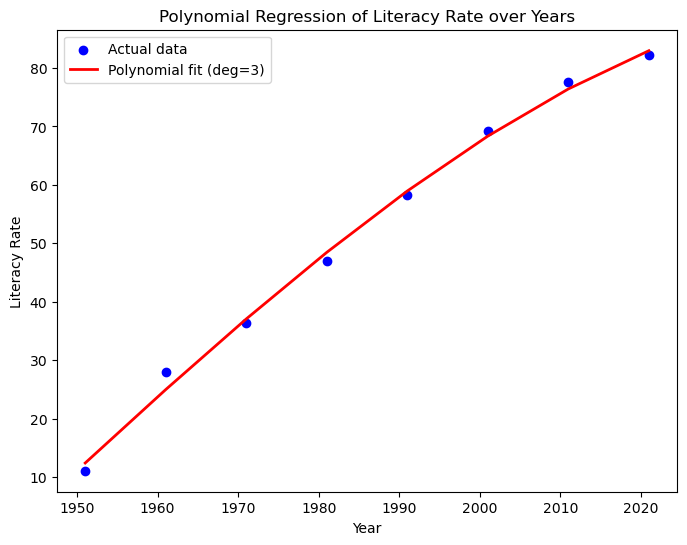

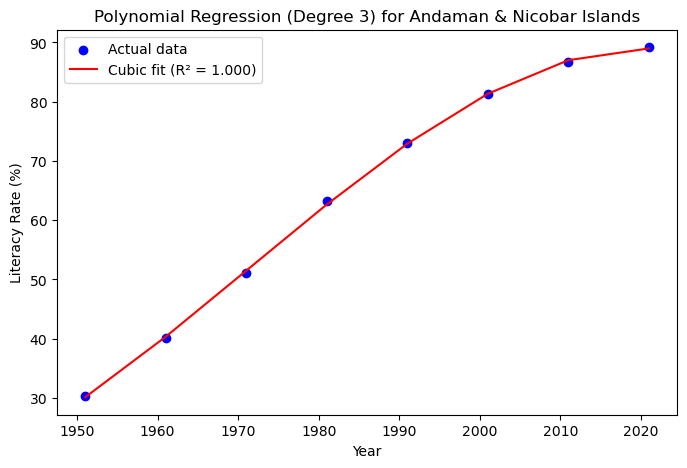

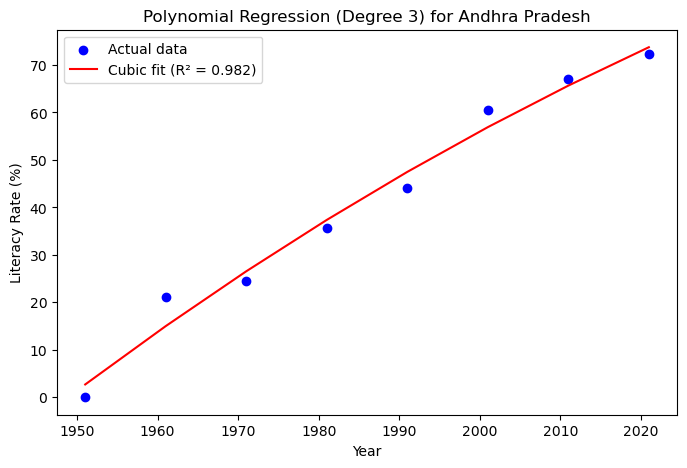

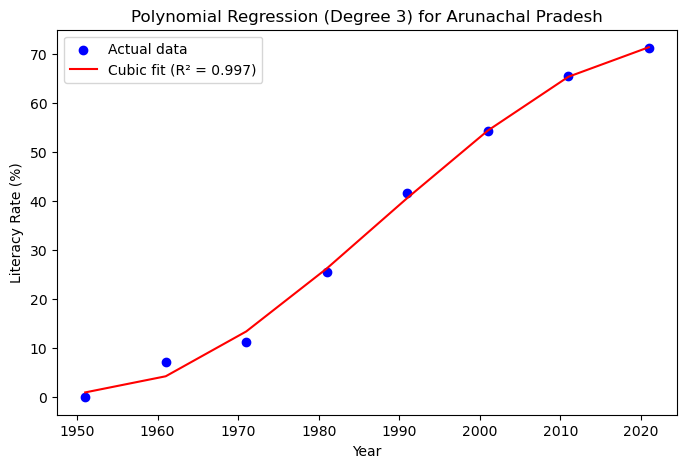

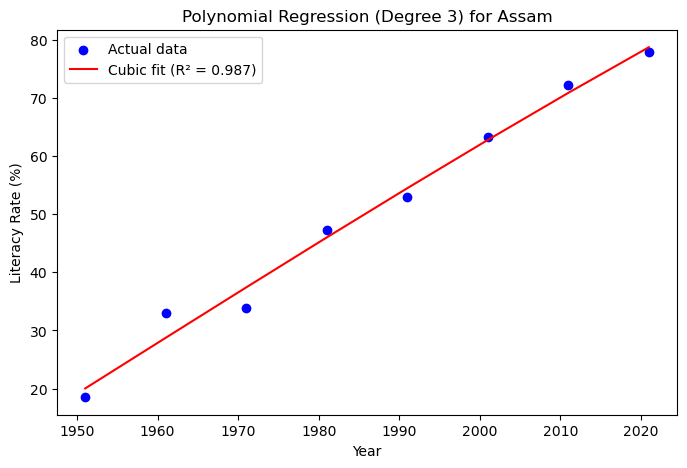

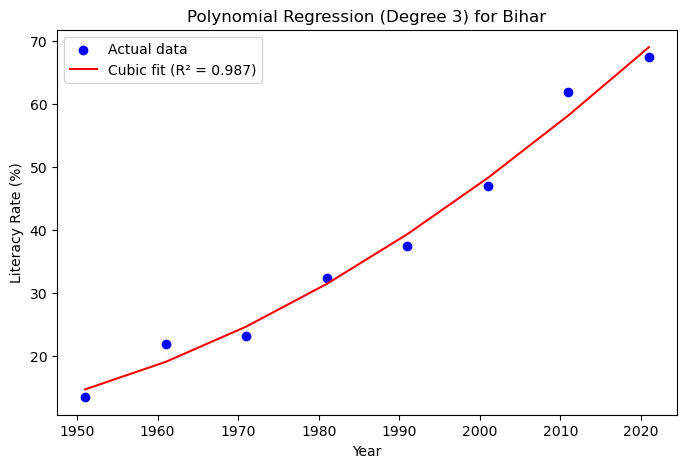

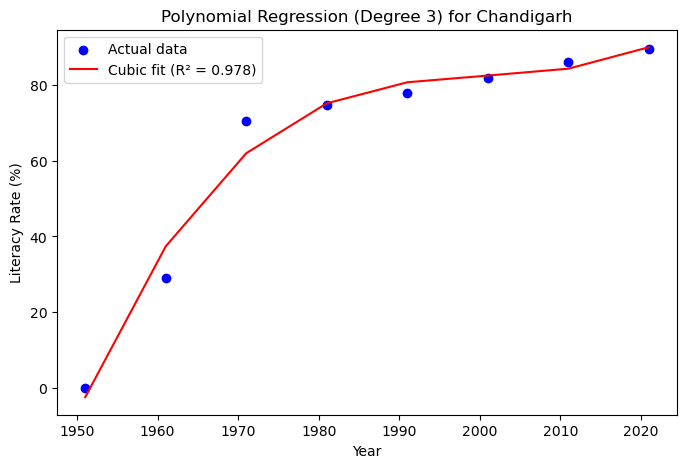

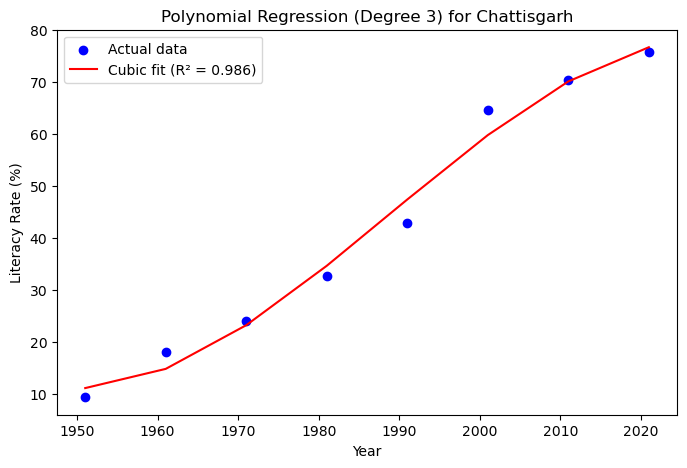

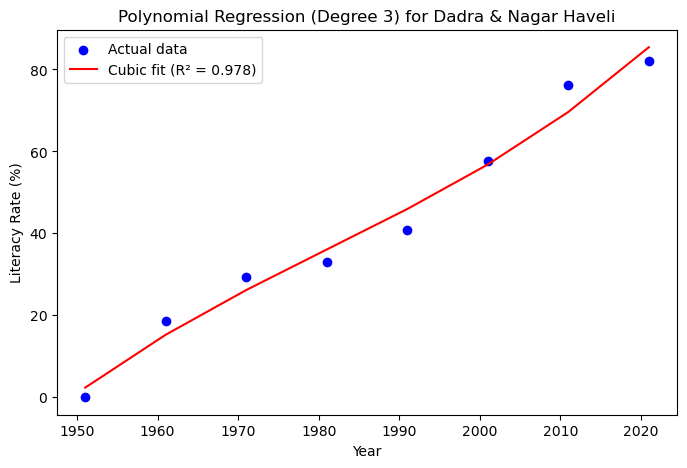

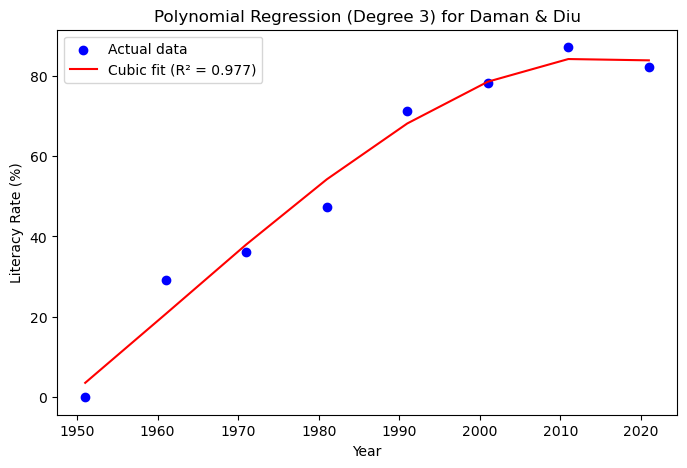

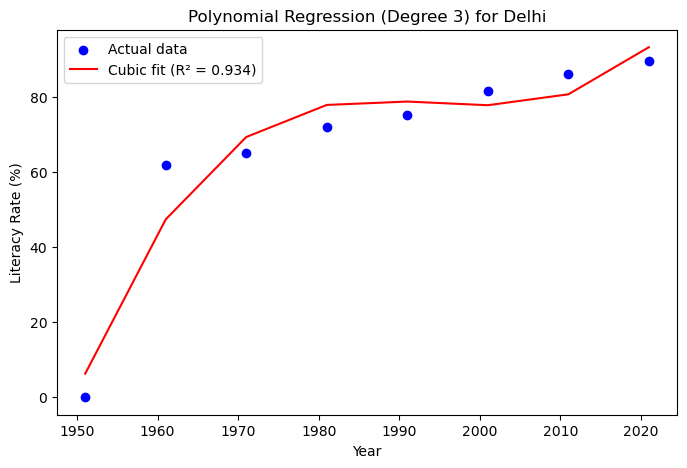

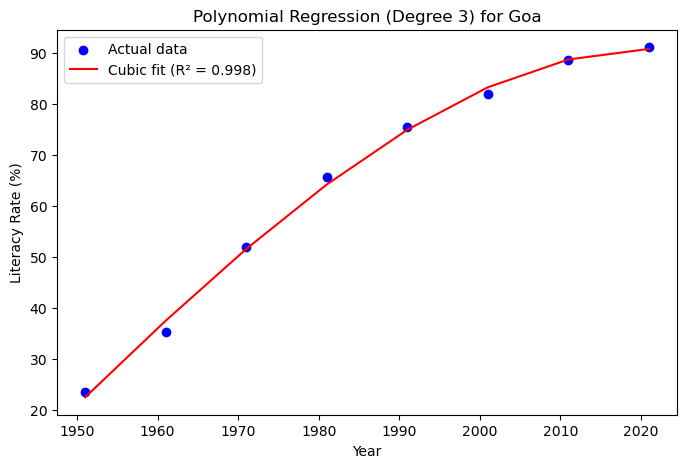

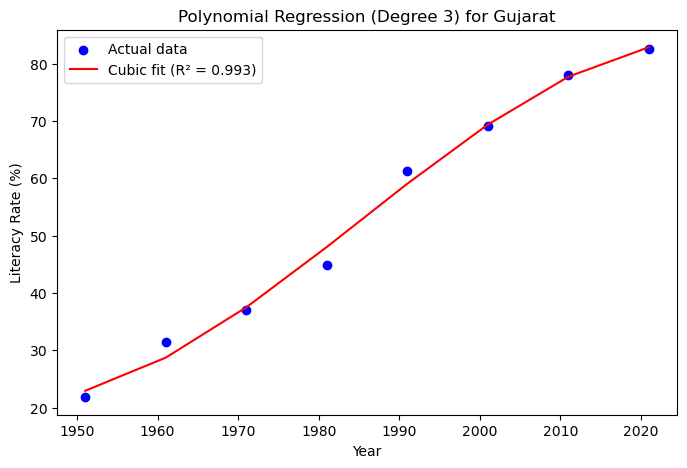

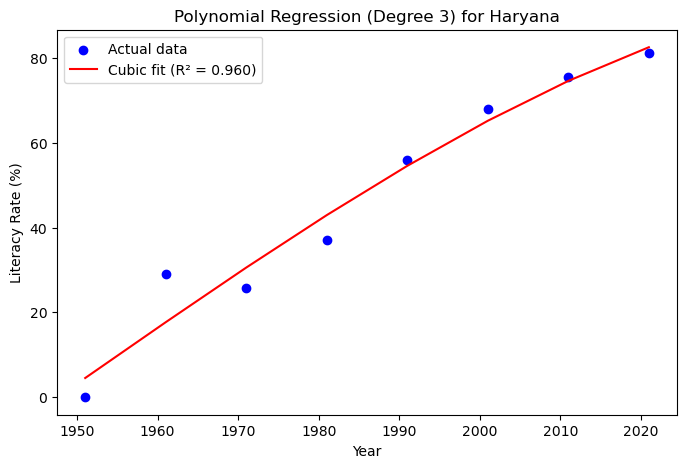

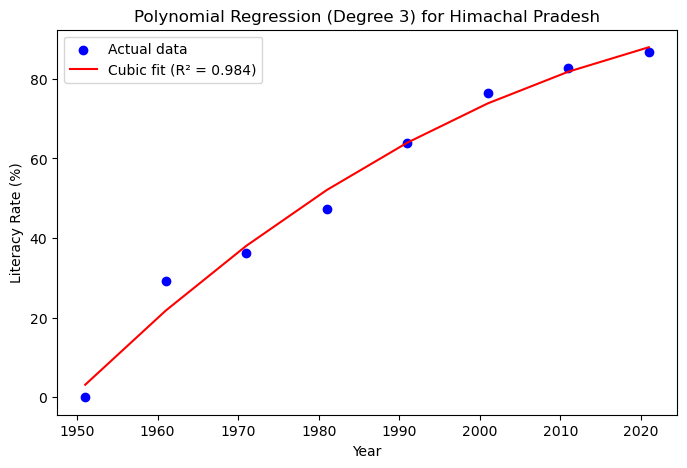

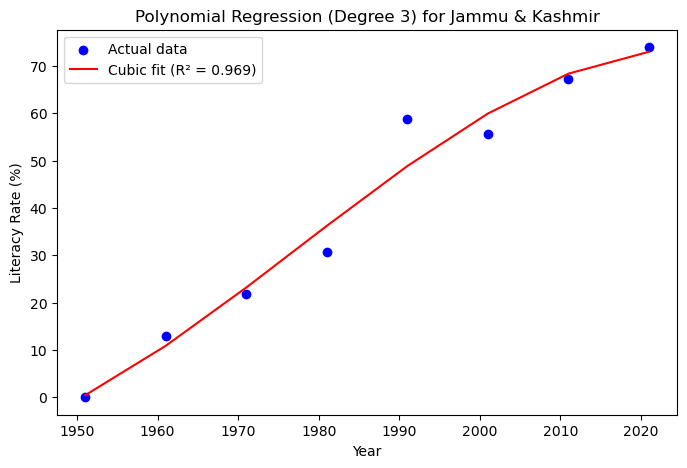

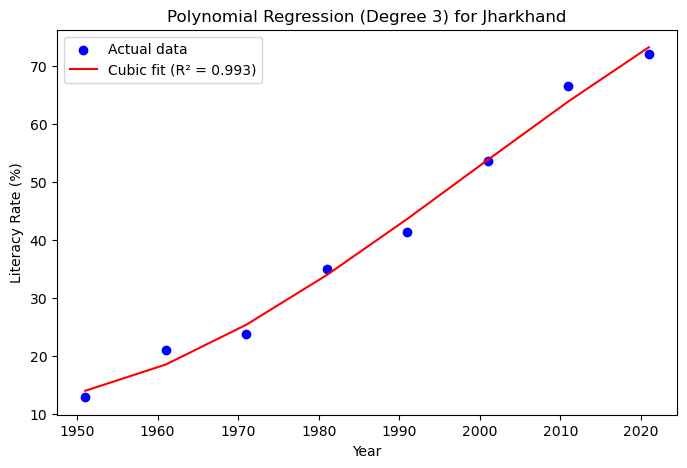

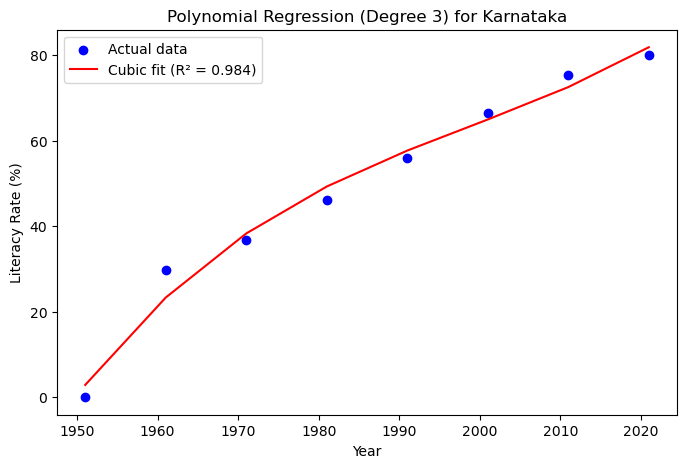

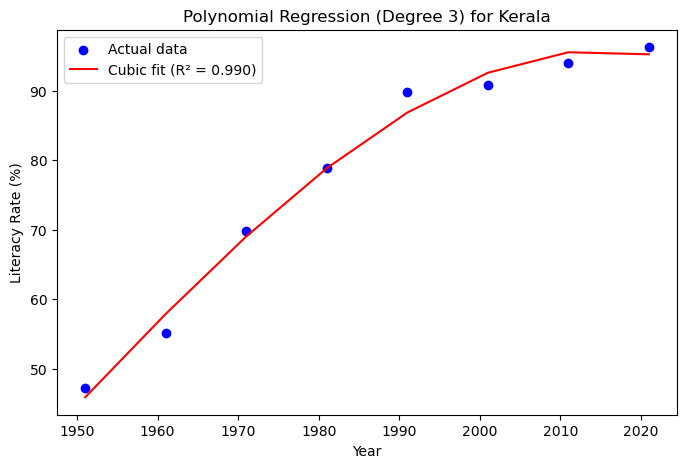

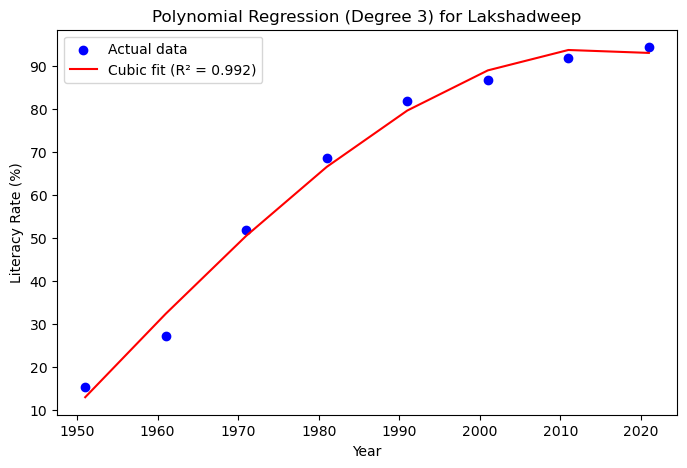

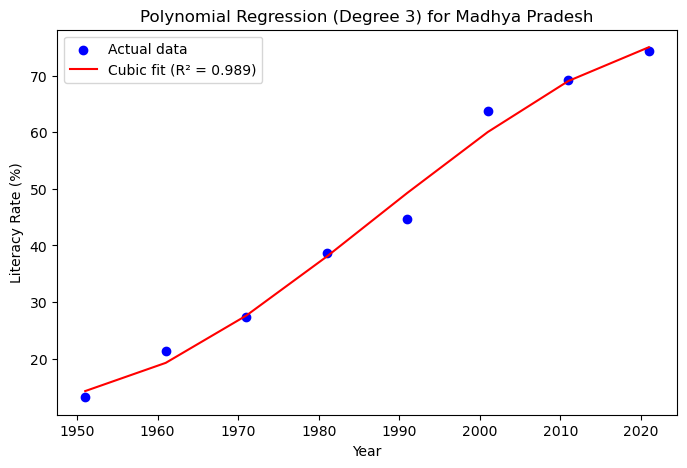

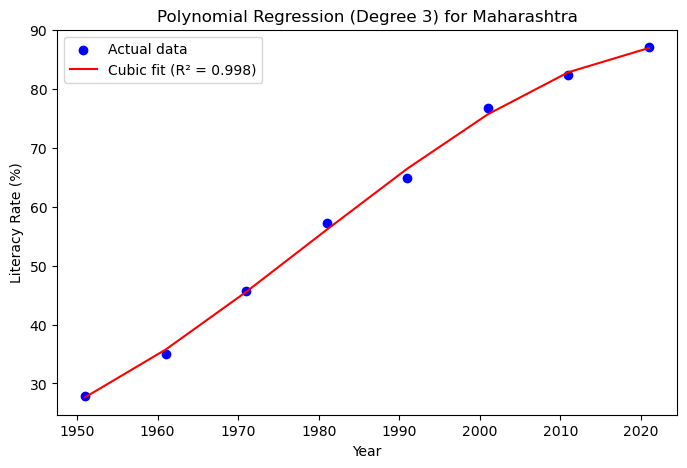

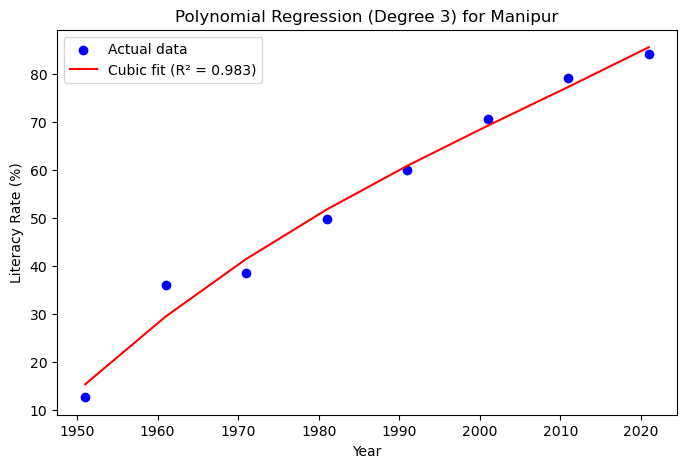

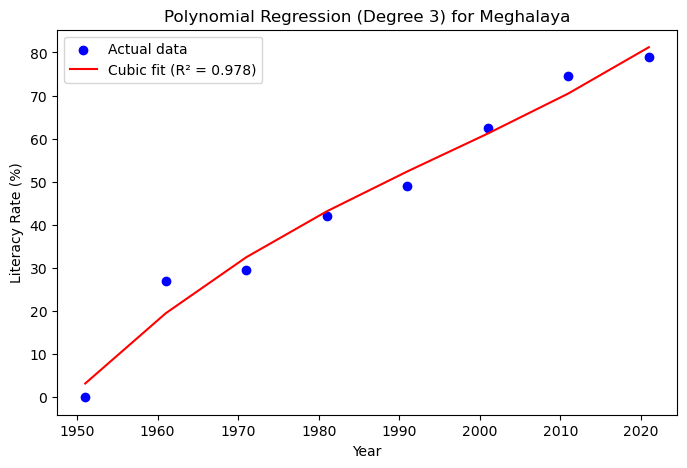

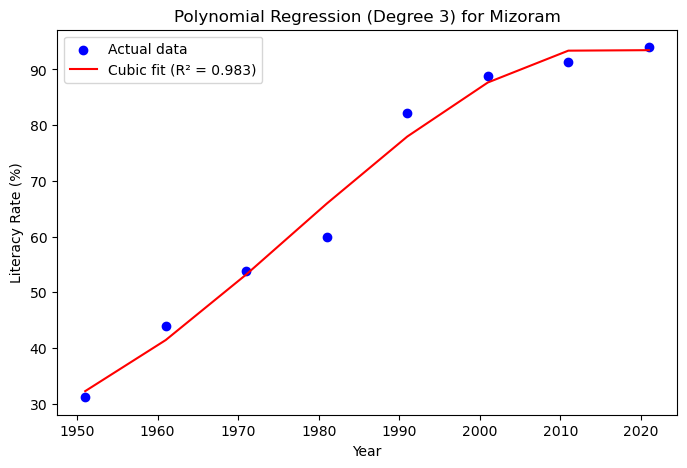

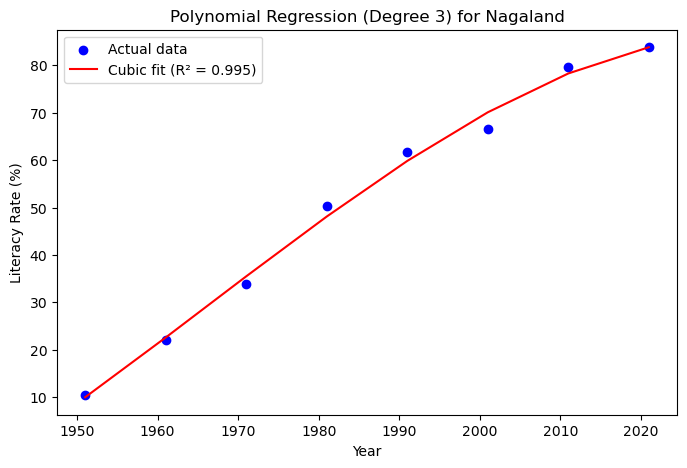

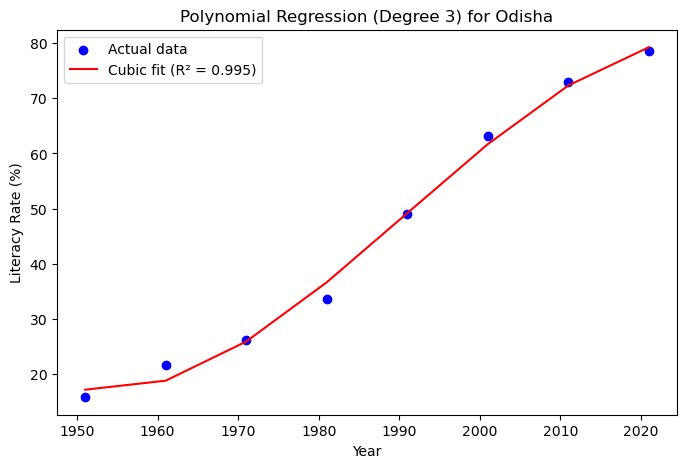

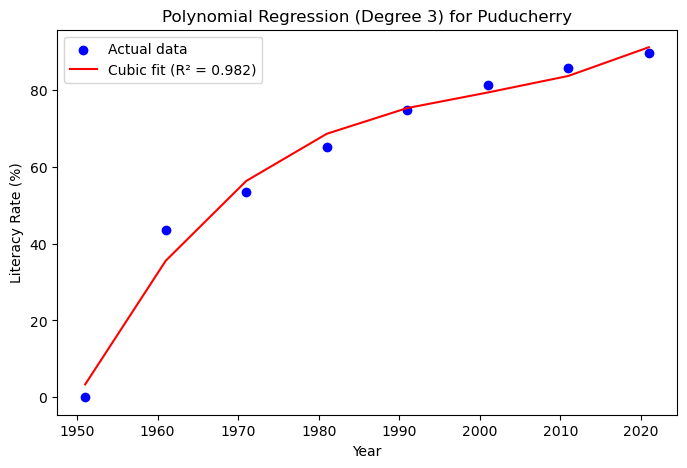

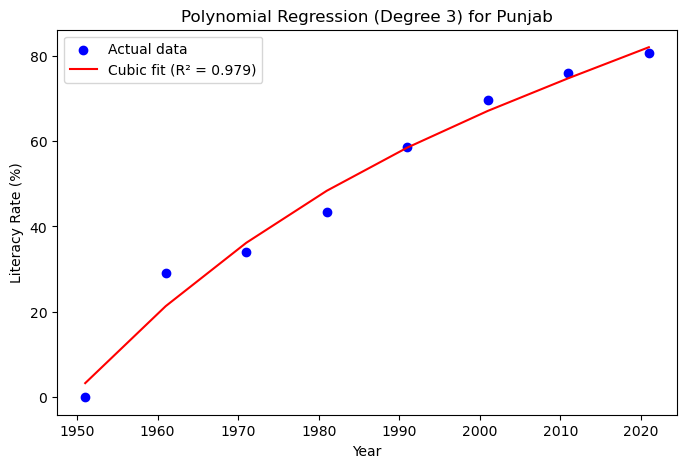

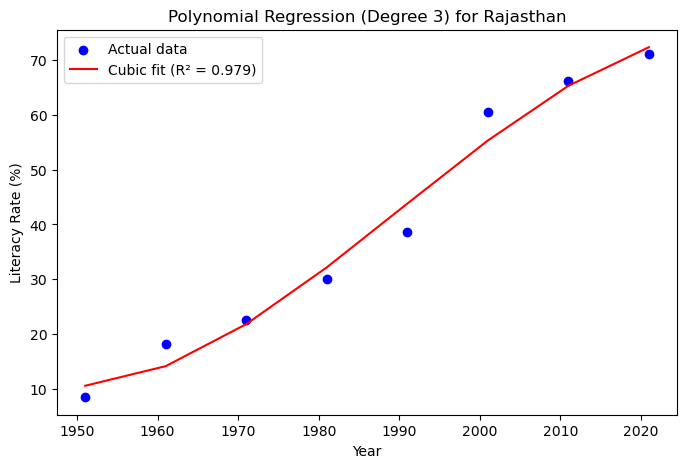

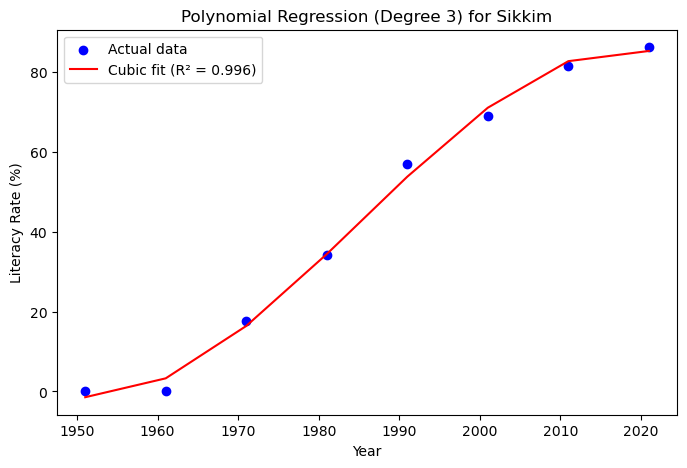

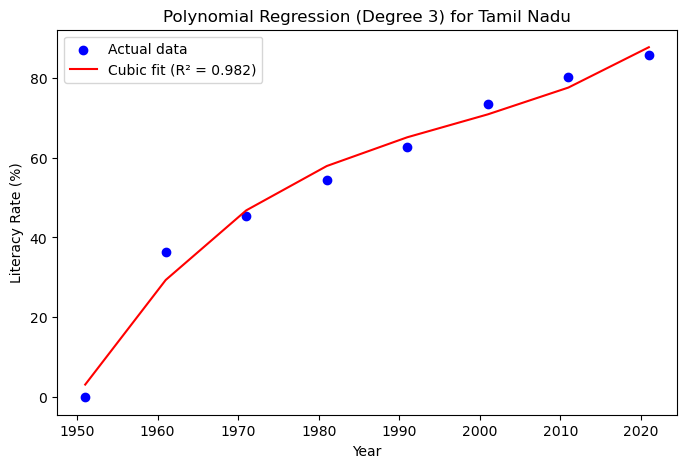

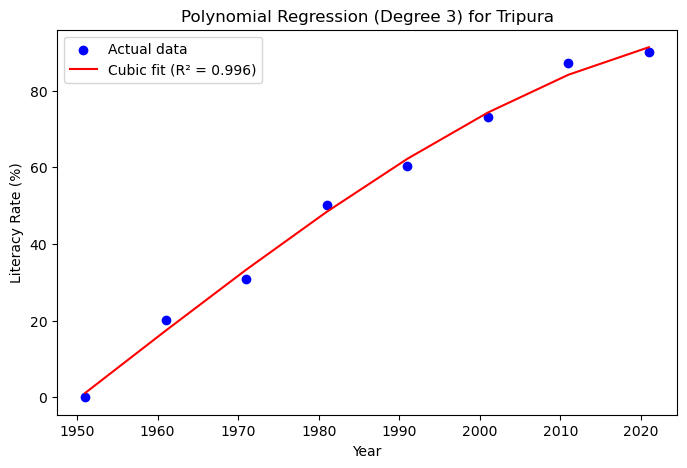

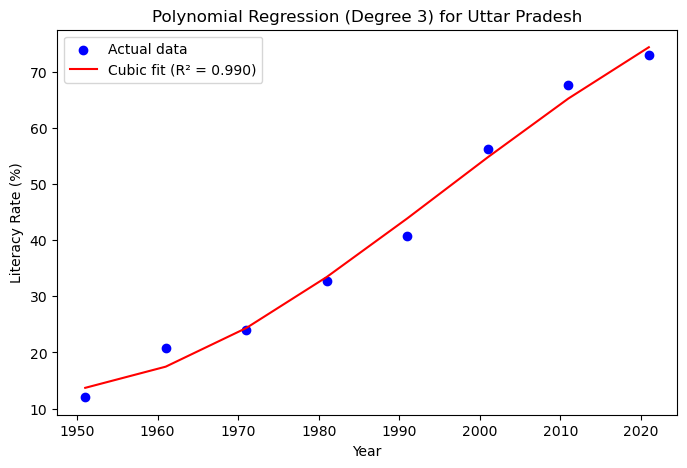

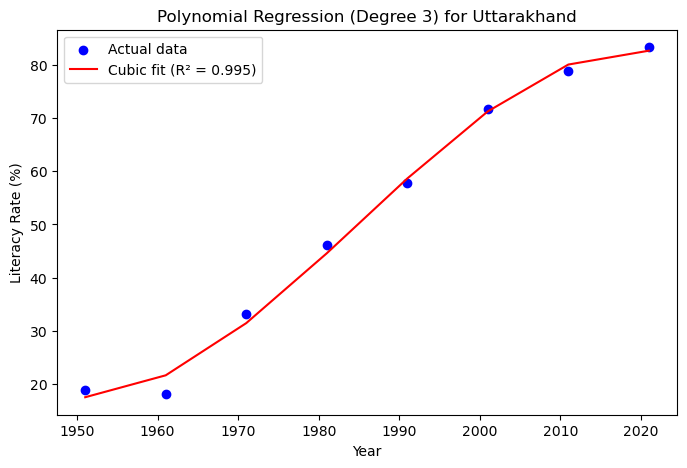

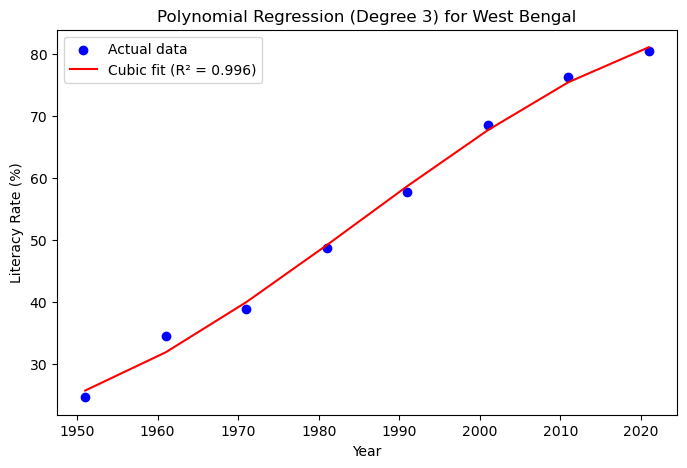

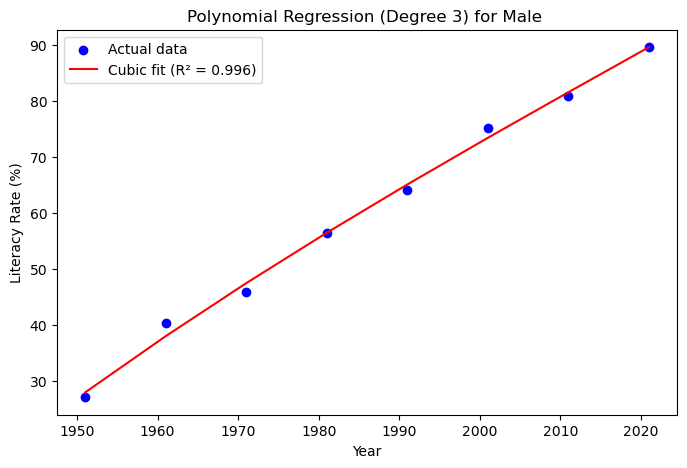

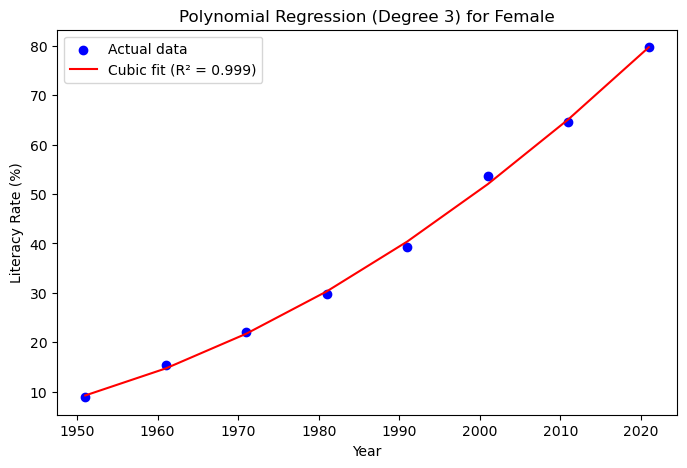

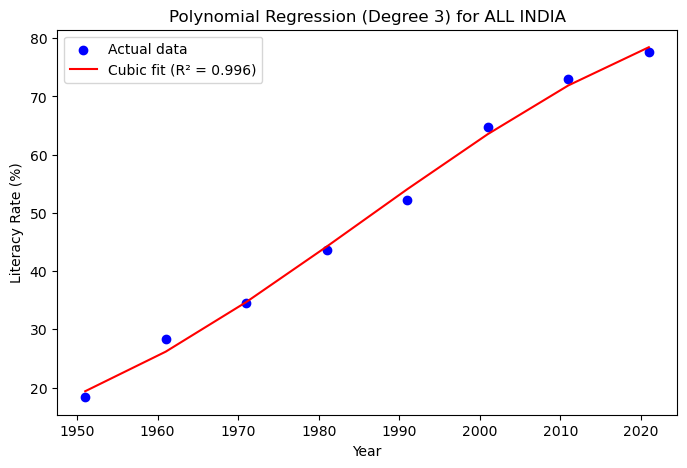

                       Entity        R²
0   Andaman & Nicobar Islands  0.999794
36                     Female  0.998827
20                Maharashtra  0.998212
10                        Goa  0.997780
2           Arunachal Pradesh  0.997152
29                     Sikkim  0.996266
37                  ALL INDIA  0.996004
34                West Bengal  0.995862
35                      Male   0.995834
31                    Tripura  0.995523
33                Uttarakhand  0.995105
24                   Nagaland  0.994901
25                     Odisha  0.994697
11                    Gujarat  0.993339
15                  Jharkhand  0.992504
18                Lakshadweep  0.991849
32              Uttar Pradesh  0.989974
17                     Kerala  0.989706
19             Madhya Pradesh  0.988784
4                       Bihar  0.987231
3                       Assam  0.987109
6                 Chattisgarh  0.985812
13           Himachal Pradesh  0.984349
16                  Karnataka  0.984141


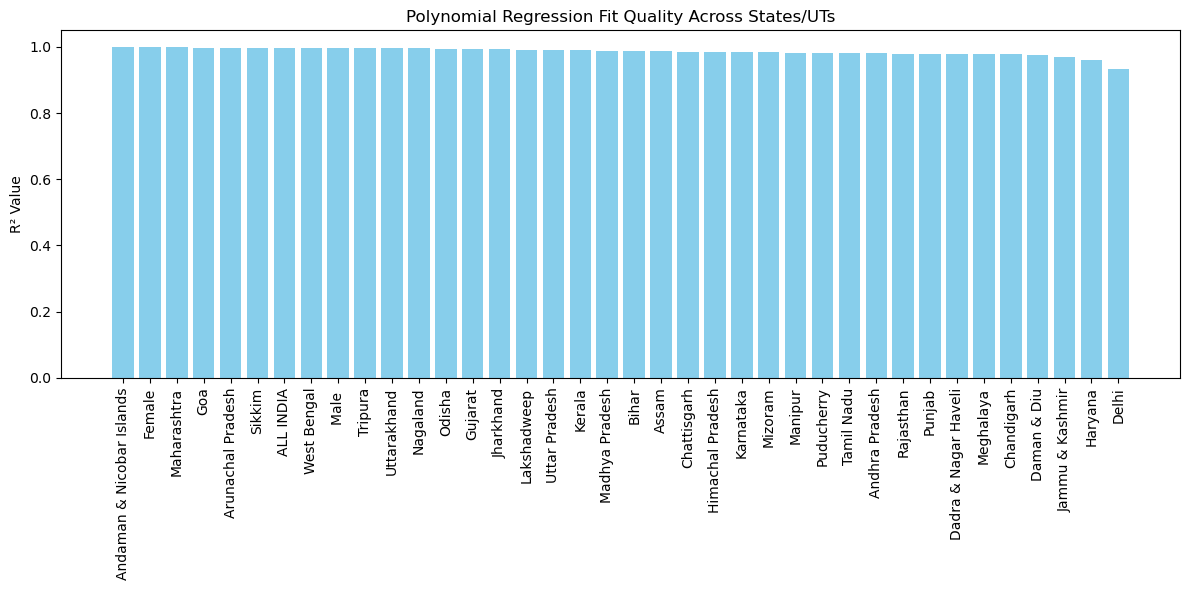

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Assuming your dataframe is named df

# Select all rows (states, UTs, Male, Female, ALL INDIA)
entities_df = df.copy()

# Extract the years (independent variable)
import re
# Convert all column names to strings first
df.columns = df.columns.astype(str)

# Drop all "Unnamed" columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Keep only columns that look like years (4-digit numbers)
year_cols = [col for col in df.columns if re.match(r'^\d{4}$', col)]

# Convert those year columns to integers
years = pd.Series(pd.to_numeric(year_cols, errors='coerce')).dropna().astype(int)
print(df.columns)
print("Year columns:", years)
  # 1951–2031

# Loop through each entity (state/UT + Male + Female + ALL INDIA)
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# --- Cleaning step ---
# Drop "Unnamed" columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Strip spaces from column names
df.columns = df.columns.str.strip()

# Identify the entity column dynamically (assume it's the first one)
entity_col = df.columns[0]

# Identify year columns (must be 4-digit numbers)
year_cols = [col for col in df.columns if re.match(r'^\d{4}$', str(col))]
years = pd.Index(year_cols).astype(int)

print("Entity column:", entity_col)
print("Year columns:", years)

# --- Regression loop ---
entities_df = df.copy()

for entity in entities_df[entity_col]:
    # Dependent variable (literacy rates for this entity)
    y = entities_df.loc[entities_df[entity_col] == entity, year_cols].values.flatten()

    # Independent variable (years)
    X = years.values.reshape(-1, 1)

    # Polynomial regression (degree 3)
    poly = PolynomialFeatures(degree=3)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    # Predict for future decades
    future_years = np.array([2041, 2051, 2061]).reshape(-1, 1)
    future_poly = poly.transform(future_years)
    predictions = model.predict(future_poly)

    # Cap predictions at 100%
    predictions = np.clip(predictions, 0, 100)

    print(f"{entity}: {dict(zip(future_years.flatten(), predictions))}")

    # Dependent variable (literacy rates of that entity)
    y = entities_df[entities_df['State/Union Territory'] == entity].iloc[:, 1:-1].values.flatten()
    
    # Independent variable (years)
    X = years.values.reshape(-1, 1)
    
    # Polynomial transformation (degree 3)
    poly = PolynomialFeatures(degree=3)
    
    # Fit regression model
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Step 1: Identify valid year columns (skip non-numeric ones)
year_columns = []
for col in df.columns:
    try:
        year_columns.append(int(col))  # keep only numeric column names
    except ValueError:
        continue  # skip non-numeric columns like "Country" or "Unnamed: X"

# Step 2: Build X and y
X = pd.Index(year_columns).values.reshape(-1, 1)
y = df.loc[:, df.columns.isin(map(str, year_columns))].mean(axis=0).values

# Step 3: Polynomial regression (degree 3)
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

#Fit regression model
model = LinearRegression()
model.fit(X_poly, y)

# Step 4: Predictions
y_pred = model.predict(X_poly)
 
# Step 5: Plot results
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color="blue", label="Actual data")
plt.plot(X, y_pred, color="red", linewidth=2, label="Polynomial fit (deg=3)")
plt.xlabel("Year")
plt.ylabel("Literacy Rate")
plt.title("Polynomial Regression of Literacy Rate over Years")
plt.legend()
plt.show()


import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Clean up column names: extract digits only
years = df.columns[1:-1].str.extract(r'(\d+)').astype(int).squeeze()

for entity in entities_df['State/Union Territory']:
    # Get literacy rates for this entity
    y = df[df['State/Union Territory'] == entity].iloc[:, 1:-1].values.flatten()
    X = years.values.reshape(-1, 1)

    # Polynomial regression (degree 3)
    poly = PolynomialFeatures(degree=3)
    X_poly = poly.fit_transform(X)
    model = LinearRegression()
    model.fit(X_poly, y)
    y_pred = model.predict(X_poly)

    # R² score 
    r2 = model.score(X_poly, y)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Copy dataframe
entities_df = df.copy()

# Extract year columns (filter out non-numeric ones like 'Unnamed')
years = [col for col in df.columns[1:] if col.replace('.', '').isdigit()]
years = np.array(years, dtype=int)

poly = PolynomialFeatures(degree=3)

# Store R² values
r2_scores = []

for entity in entities_df['State/Union Territory']:
    # Dependent variable (literacy rates)
    y = entities_df[entities_df['State/Union Territory'] == entity].iloc[:, 1:].values.flatten()

    # Independent variable (years)
    X = years.reshape(-1, 1)

    # Transform years into cubic features
    X_poly = poly.fit_transform(X)

    # Fit regression model
    model = LinearRegression()
    model.fit(X_poly, y)

    # Predictions
    y_pred = model.predict(X_poly)

    # R² score
    r2 = model.score(X_poly, y)
    r2_scores.append({"Entity": entity, "R²": r2})

    # Plot with R² in legend
    plt.figure(figsize=(8, 5))
    plt.scatter(X, y, color='blue', label='Actual data')
    plt.plot(X, y_pred, color='red', label=f'Cubic fit (R² = {r2:.3f})')
    plt.title(f'Polynomial Regression (Degree 3) for {entity}')
    plt.xlabel('Year')
    plt.ylabel('Literacy Rate (%)')
    plt.legend()
    plt.show()

# Convert to DataFrame
r2_df = pd.DataFrame(r2_scores)

# Sort by R² descending
r2_df_sorted = r2_df.sort_values(by="R²", ascending=False)
print(r2_df_sorted)

# Bar chart of R² values
plt.figure(figsize=(12, 6))
plt.bar(r2_df_sorted['Entity'], r2_df_sorted['R²'], color='skyblue')
plt.xticks(rotation=90)  # Rotate labels for readability
plt.ylabel('R² Value')
plt.title('Polynomial Regression Fit Quality Across States/UTs')
plt.tight_layout()
plt.show()

In [11]:
y_pred

array([19.3604758 , 26.1588292 , 34.68010565, 44.21957097, 54.07249099,
       63.53413153, 71.89975841, 78.46463746])

In [12]:
X

array([[1951],
       [1961],
       [1971],
       [1981],
       [1991],
       [2001],
       [2011],
       [2021]])

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Assuming your dataframe is named df
entities_df = df.copy()
years = df.columns[1:-1].astype(int)  # 1951–2031

# Prepare polynomial transformer
poly = PolynomialFeatures(degree=3)

# Dictionary to store predictions
predictions_2031 = {}

for entity in entities_df['State/Union Territory']:
    # Dependent variable (literacy rates of that entity)
    y = entities_df[entities_df['State/Union Territory'] == entity].iloc[:, 1:-1].values.flatten()
    
    # Independent variable (years)
    X = years.values.reshape(-1, 1)
    
    # Transform years into cubic features
    X_poly = poly.fit_transform(X)
    
    # Fit regression model
    model = LinearRegression()
    model.fit(X_poly, y)
    
    # Predict literacy rate for 2031
    X_future = poly.transform([[2031]])
    y_future = model.predict(X_future)[0]
    
    # Cap prediction at 100
    y_future = min(y_future, 100)
    y_future = np.clip(y_future, 0, 100)

    # Store result
    predictions_2031[entity] = y_future

# Display results
for entity, value in predictions_2031.items():
    print(f"{entity}: Predicted literacy rate in 2031 = {value:.2f}%")


Andaman & Nicobar Islands: Predicted literacy rate in 2031 = 82.54%
Andhra Pradesh: Predicted literacy rate in 2031 = 100.00%
Arunachal Pradesh: Predicted literacy rate in 2031 = 72.86%
Assam: Predicted literacy rate in 2031 = 100.00%
Bihar: Predicted literacy rate in 2031 = 100.00%
Chandigarh: Predicted literacy rate in 2031 = 100.00%
Chattisgarh: Predicted literacy rate in 2031 = 95.57%
Dadra & Nagar Haveli: Predicted literacy rate in 2031 = 100.00%
Daman & Diu: Predicted literacy rate in 2031 = 100.00%
Delhi: Predicted literacy rate in 2031 = 100.00%
Goa: Predicted literacy rate in 2031 = 82.77%
Gujarat: Predicted literacy rate in 2031 = 88.71%
Haryana: Predicted literacy rate in 2031 = 100.00%
Himachal Pradesh: Predicted literacy rate in 2031 = 100.00%
Jammu & Kashmir: Predicted literacy rate in 2031 = 54.50%
Jharkhand: Predicted literacy rate in 2031 = 100.00%
Karnataka: Predicted literacy rate in 2031 = 100.00%
Kerala: Predicted literacy rate in 2031 = 71.92%
Lakshadweep: Predict

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Load Excel
df = pd.read_excel(r"C:\pro_lit\literacy rates08.xlsx")

# Clean column names
df.columns = df.columns.map(str).str.strip()
if df.columns[0].startswith("Unnamed"):
    df.rename(columns={df.columns[0]: "State/Union Territory"}, inplace=True)

# Identify year columns directly from df
year_cols = [col for col in df.columns[1:] if str(col).replace('.', '').isdigit()]
years = np.array([int(col) for col in year_cols], dtype=int)

poly = PolynomialFeatures(degree=3)

# Loop through each entity
for entity in df["State/Union Territory"]:
    # Literacy values aligned with year columns
    y = df.loc[df["State/Union Territory"] == entity, year_cols].values.flatten()

    # Interpolate missing values
    y_series = pd.Series(y).interpolate().ffill().bfill().values

    # Independent variable (years)
    X = years.reshape(-1, 1)

    # Fit regression
    X_poly = poly.fit_transform(X)
    model = LinearRegression().fit(X_poly, y_series)

    # Predict for 2031
    y_future = model.predict(poly.fit_transform([[2031]]))[0]
    y_future = min(y_future, 100)  # cap at 100%

    # Add prediction column
    df.loc[df["State/Union Territory"] == entity, "Prediction_2031"] = y_future

# Save back to Excel
df.to_excel(r"C:\pro_lit\literacy_updated.xlsx", index=False)
